In [ ]:
import os
import subprocess
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
import torch.nn.functional as F
from google.colab import files

!nvidia-smi

Thu May 21 09:28:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
uploaded = files.upload()

with zipfile.ZipFile("proyecto_gpu.zip", "r") as z:
    z.extractall(".")

Saving proyecto_gpu.zip to proyecto_gpu.zip


In [ ]:
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image.h      -O proyecto_gpu/utils/stb_image.h
!wget -q https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h -O proyecto_gpu/utils/stb_image_write.h

In [ ]:
os.chdir("proyecto_gpu")

!nvcc -O2 -o pipeline \
    main.cu \
    kernels/grises.cu \
    kernels/bordes.cu \
    kernels/normalizar.cu \
    kernels/mse.cu \
    utils/imagen.cu \
    utils/timer.cu \
    -I utils \
    -lm

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
utils/stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

utils/stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

utils/stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

utils/stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



In [ ]:
!./pipeline

Imagen 0 RMSE: 0.000000
Imagen 1 RMSE: 0.182725
Imagen 2 RMSE: 0.182864
Imagen 3 RMSE: 0.175814
Imagen 4 RMSE: 0.210755
Imagen 5 RMSE: 0.174650
Imagen 6 RMSE: 0.186073
Imagen 7 RMSE: 0.185878

Transferencia H->D: 1.542 ms
Kernel grises: 0.224 ms
Kernel Sobel: 0.168 ms
Kernel normalizacion: 0.344 ms
Kernel RMSE: 0.223 ms
Transferencia D->H: 4.603 ms
Pipeline total: 7.205 ms
CPU equivalente: 7.448 ms
Speedup GPU vs CPU: 1.03x


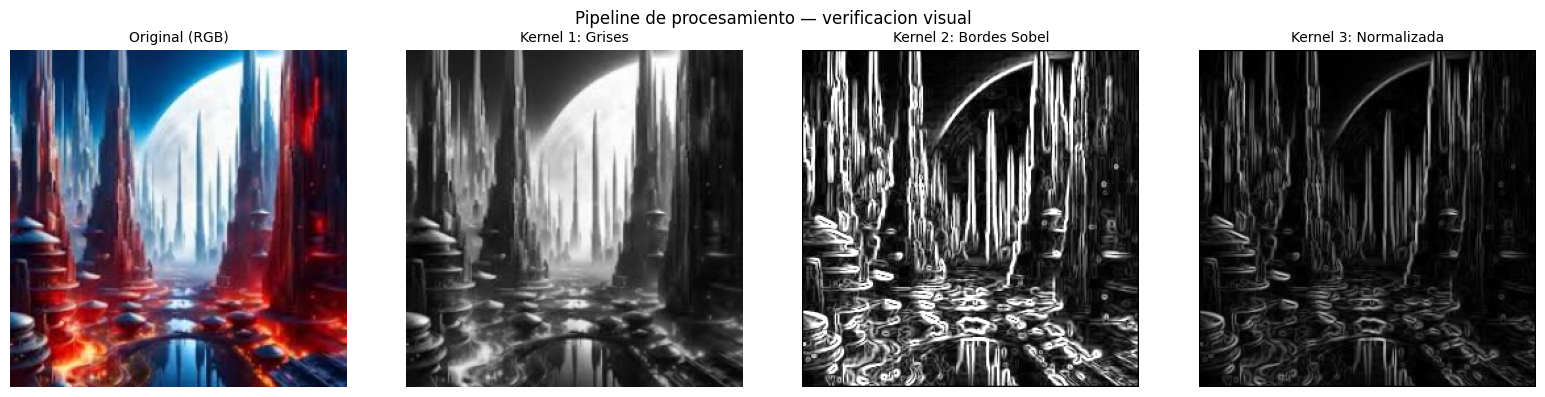

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

archivos = [
    ("resultados/imagen_00_original.png",    "Original (RGB)"),
    ("resultados/imagen_00_grises.png",      "Kernel 1: Grises"),
    ("resultados/imagen_00_bordes.png",      "Kernel 2: Bordes Sobel"),
    ("resultados/imagen_00_normalizada.png", "Kernel 3: Normalizada"),
]

for ax, (archivo, titulo) in zip(axes, archivos):
    img = mpimg.imread(archivo)
    ax.imshow(img, cmap="gray" if "original" not in archivo else None)
    ax.set_title(titulo, fontsize=10)
    ax.axis("off")

plt.suptitle("Pipeline de procesamiento — verificacion visual", fontsize=12)
plt.tight_layout()
plt.savefig("resultados/verificacion_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
img_gris = mpimg.imread("resultados/imagen_00_grises.png").astype(np.float32)
if img_gris.ndim == 3:
    img_gris = img_gris[:, :, 0]

t = torch.tensor(img_gris).unsqueeze(0).unsqueeze(0)

sobel_x = torch.tensor([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=torch.float32).view(1, 1, 3, 3)

sobel_y = torch.tensor([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=torch.float32).view(1, 1, 3, 3)

Gx = F.conv2d(t, sobel_x, padding=1)
Gy = F.conv2d(t, sobel_y, padding=1)
mag_pytorch = torch.sqrt(Gx**2 + Gy**2).squeeze().numpy()

mag_pytorch[0,  :]  = 0
mag_pytorch[-1, :]  = 0
mag_pytorch[:,  0]  = 0
mag_pytorch[:, -1]  = 0

img_bordes_png = mpimg.imread("resultados/imagen_00_bordes.png").astype(np.float32)
if img_bordes_png.ndim == 3:
    img_bordes_png = img_bordes_png[:, :, 0]

mag_pytorch_clamped = np.clip(mag_pytorch, 0.0, 1.0)

H, W = img_gris.shape
cuda_interior  = img_bordes_png[1:H-1, 1:W-1]
torch_interior = mag_pytorch_clamped[1:H-1, 1:W-1]

diferencia = np.abs(cuda_interior - torch_interior).mean()

print(f"Diferencia promedio: {diferencia:.6f}")
print("PASADA" if diferencia < 0.01 else "FALLIDA")

Diferencia promedio: 0.003494
PASADA


In [ ]:
resultado = subprocess.run(["./pipeline"], capture_output=True, text=True)
salida = resultado.stdout

print(salida)

print("| Etapa                | Tiempo (ms) |")
print("|----------------------|-------------|")

mapeo = [
    ("Transferencia H->D",   "Transferencia H→D   "),
    ("Kernel grises",        "Kernel grises        "),
    ("Kernel Sobel",         "Kernel Sobel         "),
    ("Kernel normalizacion", "Kernel normalizacion "),
    ("Kernel RMSE",          "Kernel RMSE          "),
    ("Transferencia D->H",   "Transferencia D→H   "),
    ("Pipeline total",       "**Pipeline total**   "),
    ("CPU equivalente",      "CPU equivalente      "),
]

for clave, etiqueta in mapeo:
    for linea in salida.split("\n"):
        if clave in linea and "ms" in linea:
            valor = linea.split(":")[1].strip()
            print(f"| {etiqueta}| {valor:<11} |")
            break

for linea in salida.split("\n"):
    if "Speedup" in linea:
        partes = linea.strip().split(":")
        print(f"| **Speedup**          | {partes[1].strip():<11} |")
        break

Imagen 0 RMSE: 0.000000
Imagen 1 RMSE: 0.182725
Imagen 2 RMSE: 0.182864
Imagen 3 RMSE: 0.175814
Imagen 4 RMSE: 0.210755
Imagen 5 RMSE: 0.174650
Imagen 6 RMSE: 0.186073
Imagen 7 RMSE: 0.185878

Transferencia H->D: 1.519 ms
Kernel grises: 0.252 ms
Kernel Sobel: 0.152 ms
Kernel normalizacion: 0.248 ms
Kernel RMSE: 0.191 ms
Transferencia D->H: 4.756 ms
Pipeline total: 7.202 ms
CPU equivalente: 7.465 ms
Speedup GPU vs CPU: 1.04x

| Etapa                | Tiempo (ms) |
|----------------------|-------------|
| Transferencia H→D   | 1.519 ms    |
| Kernel grises        | 0.252 ms    |
| Kernel Sobel         | 0.152 ms    |
| Kernel normalizacion | 0.248 ms    |
| Kernel RMSE          | 0.191 ms    |
| Transferencia D→H   | 4.756 ms    |
| **Pipeline total**   | 7.202 ms    |
| CPU equivalente      | 7.465 ms    |
| **Speedup**          | 1.04x       |


In [ ]:
os.chdir("..")

with zipfile.ZipFile("resultados_pipeline.zip", "w") as z:
    for f in os.listdir("proyecto_gpu/resultados"):
        z.write(f"proyecto_gpu/resultados/{f}", f"resultados/{f}")

files.download("resultados_pipeline.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>